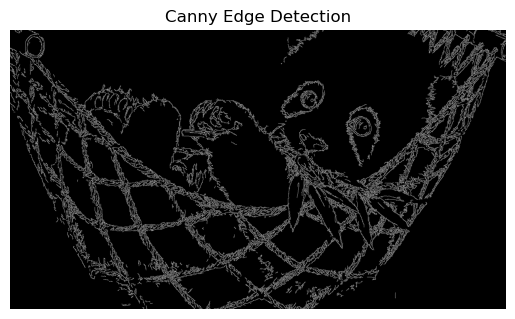

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
image = cv2.imread(r"C:\Users\rithi\Downloads\pandascv.jpg")

edges = cv2.Canny(image, 100, 200)  

# Display the result
plt.imshow(edges, cmap='gray')
plt.title('Canny Edge Detection')
plt.axis('off')
plt.show()

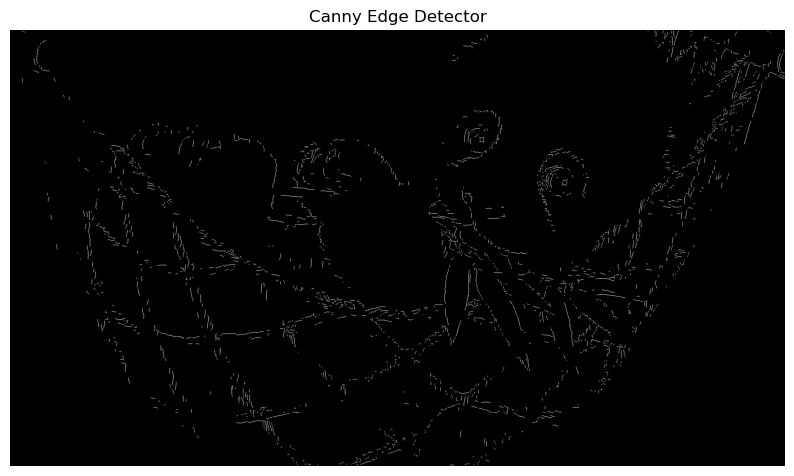

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def grayscale(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

def gaussian_blur(image, kernel_size):
    return cv2.GaussianBlur(image, (kernel_size, kernel_size), 0)

def sobel_gradients(image):
    sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
    magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
    angle = np.arctan2(sobel_y, sobel_x)
    return magnitude, angle

def non_maximum_suppression(magnitude, angle):
    angle = angle * 180.0 / np.pi
    angle[angle < 0] += 180
    suppressed = np.zeros_like(magnitude)
    for i in range(1, magnitude.shape[0] - 1):
        for j in range(1, magnitude.shape[1] - 1):
            q = 255
            r = 255
            if (0 <= angle[i, j] < 22.5) or (157.5 <= angle[i, j] <= 180):
                q = magnitude[i, j + 1]
                r = magnitude[i, j - 1]
            elif 22.5 <= angle[i, j] < 67.5:
                q = magnitude[i + 1, j - 1]
                r = magnitude[i - 1, j + 1]
            elif 67.5 <= angle[i, j] < 112.5:
                q = magnitude[i + 1, j]
                r = magnitude[i - 1, j]
            elif 112.5 <= angle[i, j] < 157.5:
                q = magnitude[i - 1, j - 1]
                r = magnitude[i + 1, j + 1]
            if magnitude[i, j] >= q and magnitude[i, j] >= r:
                suppressed[i, j] = magnitude[i, j]
            else:
                suppressed[i, j] = 0
    return suppressed

def hysteresis_thresholding(suppressed, low_threshold, high_threshold):
    edges = np.zeros_like(suppressed)
    strong = 255
    weak = 50
    strong_i, strong_j = np.where(suppressed >= high_threshold)
    weak_i, weak_j = np.where((suppressed <= high_threshold) & (suppressed >= low_threshold))
    edges[strong_i, strong_j] = strong
    edges[weak_i, weak_j] = weak
    for i in range(1, suppressed.shape[0] - 1):
        for j in range(1, suppressed.shape[1] - 1):
            if edges[i, j] == weak:
                if strong in [edges[i+1, j-1], edges[i+1, j], edges[i+1, j+1], edges[i, j-1], edges[i, j+1], edges[i-1, j-1], edges[i-1, j], edges[i-1, j+1]]:
                    edges[i, j] = strong
                else:
                    edges[i, j] = 0
    return edges

def canny_edge_detector(image_path, low_threshold, high_threshold):
    image = cv2.imread(image_path)
    gray_image = grayscale(image)
    blurred_image = gaussian_blur(gray_image, 5)
    magnitude, angle = sobel_gradients(blurred_image)
    suppressed = non_maximum_suppression(magnitude, angle)
    edges = hysteresis_thresholding(suppressed, low_threshold, high_threshold)
    return edges

# Example usage
image_path = (r"C:\Users\rithi\Downloads\pandascv.jpg")
low_threshold = 50
high_threshold = 150

edges = canny_edge_detector(image_path, low_threshold, high_threshold)

# Display the edges using Matplotlib
plt.figure(figsize=(10, 6))
plt.imshow(edges, cmap='gray')
plt.title('Canny Edge Detector')
plt.axis('off')
plt.show()


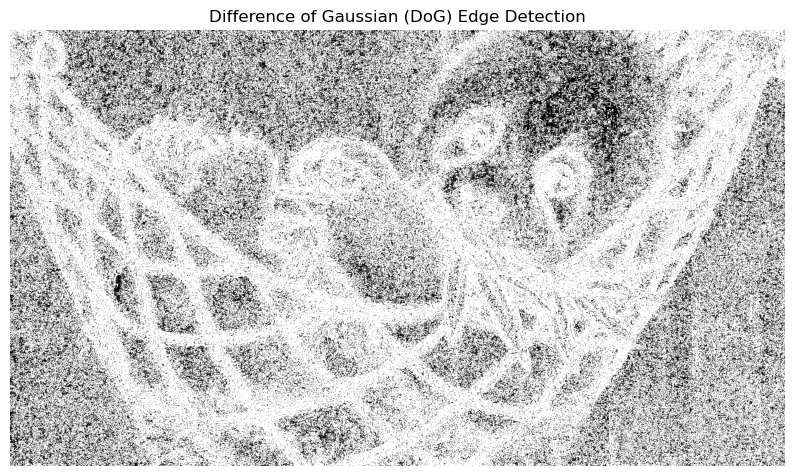

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
def difference_of_gaussian(image, sigma1, sigma2):
    blurred_image1 = gaussian_filter(image, sigma1)
    blurred_image2 = gaussian_filter(image, sigma2)
    dog_image = blurred_image1 - blurred_image2
    return dog_image
def dog_edge_detection(image, sigma1=1.0, sigma2=2.0):
    if len(image.shape) == 3:
        image = np.mean(image, axis=2) 
    dog_edges = difference_of_gaussian(image, sigma1, sigma2)
    dog_edges[dog_edges > 0] = 1
    dog_edges[dog_edges <= 0] = 0
    return dog_edges
dog_edges = dog_edge_detection(image, sigma1=1.0, sigma2=2.0)
plt.figure(figsize=(10, 10))
plt.imshow(dog_edges, cmap='gray')
plt.title("Difference of Gaussian (DoG) Edge Detection")
plt.axis('off')
plt.show()


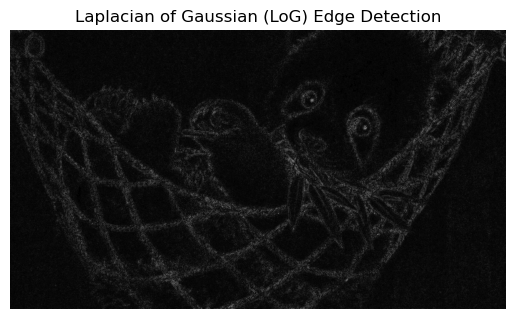

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# Load the image in grayscale
image = cv2.imread(r"C:\Users\rithi\Downloads\pandascv.jpg", cv2.IMREAD_GRAYSCALE)

# Apply Gaussian filter (smooth the image)
sigma = 1  # Standard deviation for the Gaussian kernel
smoothed_image = gaussian_filter(image, sigma=sigma)

# Apply the Laplacian of Gaussian (LoG)
log_image = cv2.Laplacian(smoothed_image, cv2.CV_64F)

# Convert to absolute value to make the edges more visible
log_image = cv2.convertScaleAbs(log_image)

# Display the result
plt.imshow(log_image, cmap='gray')
plt.title('Laplacian of Gaussian (LoG) Edge Detection')
plt.axis('off')
plt.show()


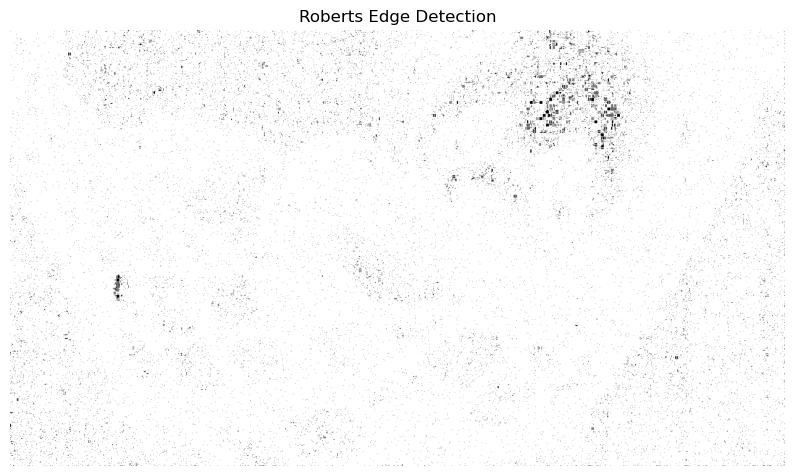

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve
def roberts_kernels():
    kernel_x = np.array([[1, 0],
                         [0, -1]])
    kernel_y = np.array([[0, 1],
                         [-1, 0]])
    return kernel_x, kernel_y
def roberts_edge_detection(image):
    if len(image.shape) == 3:
        image = np.mean(image, axis=2) 
    kernel_x, kernel_y = roberts_kernels()
    grad_x = convolve(image, kernel_x)
    grad_y = convolve(image, kernel_y)
    magnitude = np.sqrt(grad_x**2 + grad_y**2)
    edges = np.where(magnitude > 0, 1, 0)
    return edges
edges = roberts_edge_detection(image)
plt.figure(figsize=(10, 10))
plt.imshow(edges, cmap='gray')
plt.title("Roberts Edge Detection")
plt.axis('off')
plt.show()


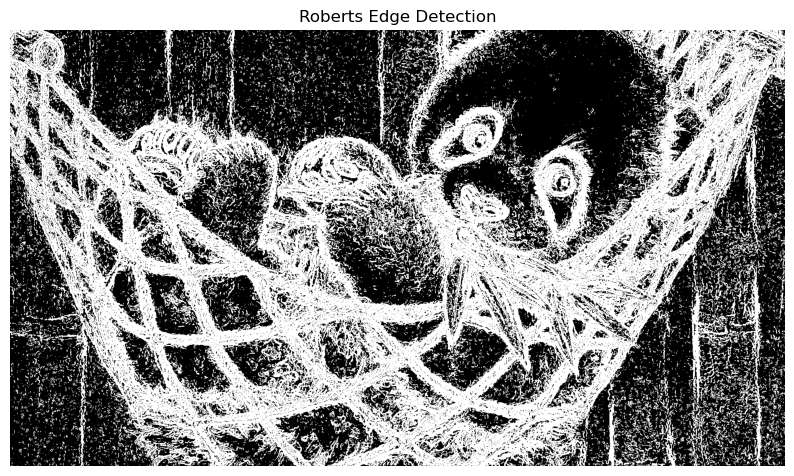

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import imageio.v3 as imageio
from scipy.ndimage import convolve, gaussian_filter

def roberts_kernels():
    kernel_x = np.array([[1, 0],
                         [0, -1]])
    kernel_y = np.array([[0, 1],
                         [-1, 0]])
    return kernel_x, kernel_y

def roberts_edge_detection(image, sigma=1.0, threshold_ratio=0.3):
    # Convert to grayscale if image is colored
    if len(image.shape) == 3:
        image = np.mean(image, axis=2)

    # Normalize image
    image = image.astype(np.float32) / 255.0  

    # Apply Gaussian blur to reduce noise
    image = gaussian_filter(image, sigma=sigma)

    kernel_x, kernel_y = roberts_kernels()
    grad_x = convolve(image, kernel_x, mode='reflect')
    grad_y = convolve(image, kernel_y, mode='reflect')

    magnitude = np.sqrt(grad_x**2 + grad_y**2)

    # Normalize magnitude
    magnitude = magnitude / np.max(magnitude)

    # Dynamic thresholding
    threshold = np.percentile(magnitude, 75) * threshold_ratio
    edges = (magnitude > threshold).astype(np.uint8)

    return edges
    
edges = roberts_edge_detection(image, sigma=1.0, threshold_ratio=0.5)

# Display result
plt.figure(figsize=(10, 10))
plt.imshow(edges, cmap='gray')
plt.title("Roberts Edge Detection")
plt.axis('off')
plt.show()


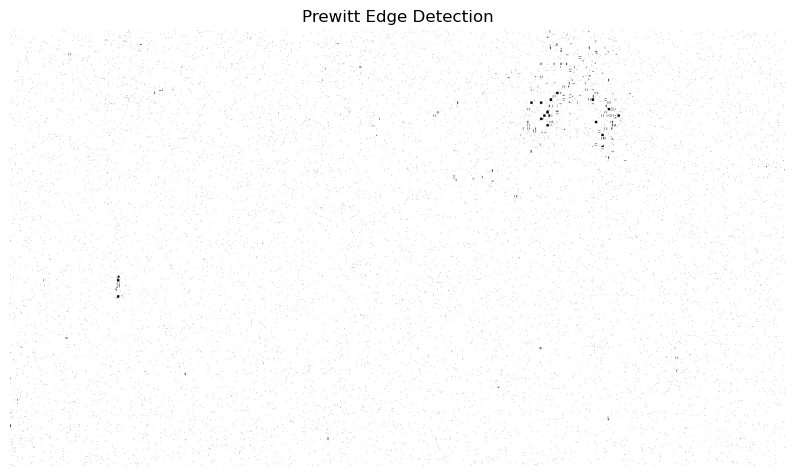

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve
def prewitt_kernels():
    kernel_x = np.array([[-1, 0, 1],
                         [-1, 0, 1],
                         [-1, 0, 1]])

    kernel_y = np.array([[-1, -1, -1],
                         [ 0, 0, 0],
                         [ 1, 1, 1]])

    return kernel_x, kernel_y
def prewitt_edge_detection(image):
    if len(image.shape) == 3:
        image = np.mean(image, axis=2) 
    kernel_x, kernel_y = prewitt_kernels()
    grad_x = convolve(image, kernel_x)
    grad_y = convolve(image, kernel_y)
    magnitude = np.sqrt(grad_x**2 + grad_y**2)
    edges = np.where(magnitude > 0, 1, 0)
    return edges
edges = prewitt_edge_detection(image)
plt.figure(figsize=(10, 10))
plt.imshow(edges, cmap='gray')
plt.title("Prewitt Edge Detection")
plt.axis('off')
plt.show()

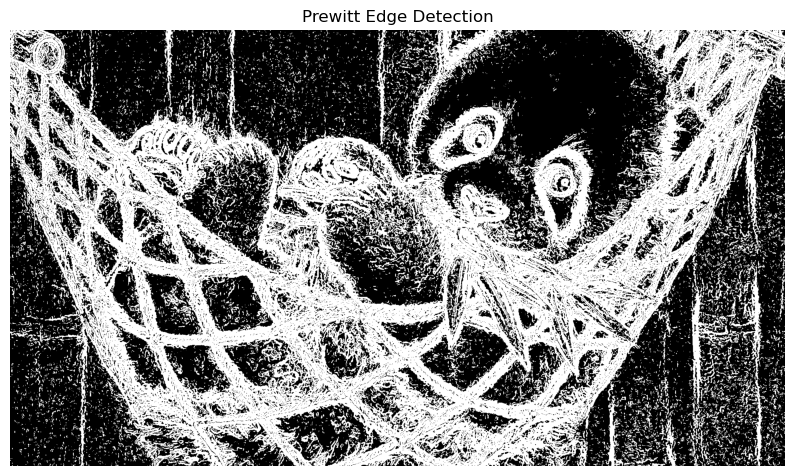

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import imageio.v3 as imageio
from scipy.ndimage import convolve, gaussian_filter

def prewitt_kernels():
    kernel_x = np.array([[-1, 0, 1],
                         [-1, 0, 1],
                         [-1, 0, 1]])

    kernel_y = np.array([[-1, -1, -1],
                         [ 0,  0,  0],
                         [ 1,  1,  1]])
    return kernel_x, kernel_y

def prewitt_edge_detection(image, sigma=1.0, threshold_ratio=0.2):
    # Convert to grayscale if image is colored
    if len(image.shape) == 3:
        image = np.mean(image, axis=2)

    # Normalize image
    image = image.astype(np.float32) / 255.0  

    # Apply Gaussian blur to reduce noise
    image = gaussian_filter(image, sigma=sigma)

    kernel_x, kernel_y = prewitt_kernels()
    grad_x = convolve(image, kernel_x, mode='reflect')
    grad_y = convolve(image, kernel_y, mode='reflect')

    magnitude = np.sqrt(grad_x**2 + grad_y**2)

    # Normalize magnitude
    magnitude = magnitude / np.max(magnitude)

    # Apply dynamic threshold
    threshold = np.percentile(magnitude, 75) * threshold_ratio
    edges = (magnitude > threshold).astype(np.uint8)

    return edges

# Load and process image
image = imageio.imread(r"C:\Users\rithi\Downloads\pandascv.jpg")  # Replace with your image file path
edges = prewitt_edge_detection(image, sigma=1.0, threshold_ratio=0.5)

# Display result
plt.figure(figsize=(10, 10))
plt.imshow(edges, cmap='gray')
plt.title("Prewitt Edge Detection")
plt.axis('off')
plt.show()
